## IMPORTS

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os
import joblib

## CONSTANTS

In [2]:
NUMERICAL_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

CATEGORICAL_COLS = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

TARGET_COL = 'target'

## Step 1.1 — Load Dataset

In [3]:
def load_dataset(input_path: str) -> pd.DataFrame:
    df = pd.read_csv(input_path)
    print(f"  Original shape : {df.shape}")
    print(f"  Columns        : {list(df.columns)}")
    return df

## Step 1.2 — Save Raw Backup

In [4]:
def save_raw_backup(df: pd.DataFrame, raw_path: str) -> None:
    os.makedirs(os.path.dirname(raw_path), exist_ok=True)
    df.to_csv(raw_path, index=False)
    print(f"  Raw backup saved to: {raw_path}")

## Step 1.3 — Remove Duplicates

In [5]:
df = load_dataset("../data/raw_data.csv")

print("\nChecking for duplicates")
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
removed = before_rows - after_rows
print(f"  Rows before       : {before_rows}")
print(f"  Rows after        : {after_rows}")
print(f"  Duplicates removed: {removed}")

  Original shape : (1025, 14)
  Columns        : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Checking for duplicates
  Rows before       : 1025
  Rows after        : 305
  Duplicates removed: 720


## Step 1.4 — Handle Missing Values

In [6]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    print("\nHandling missing values")

    for col in NUMERICAL_COLS:
        if col in df.columns and df[col].isnull().sum() > 0:
            mean_val = df[col].mean()
            df[col] = df[col].fillna(mean_val)
            print(f"  Filled '{col}' with mean ({mean_val:.2f})")

    for col in CATEGORICAL_COLS:
        if col in df.columns and df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  Filled '{col}' with mode ({mode_val})")

    return df

## Step 1.5 — Normalize Numerical Features

In [7]:
def normalize_features(df: pd.DataFrame, scaler_path: str) -> pd.DataFrame:
    print("\nNormalizing numerical features")

    existing_num_cols = [col for col in NUMERICAL_COLS if col in df.columns]

    scaler = MinMaxScaler()
    df[existing_num_cols] = scaler.fit_transform(df[existing_num_cols])

    os.makedirs(os.path.dirname(scaler_path), exist_ok=True)
    joblib.dump(scaler, scaler_path)

    print(f"  Scaled columns : {existing_num_cols}")
    print(f"  Scaler saved to: {scaler_path}")

    return df

## Step 1.6 — Encode Categorical Variables

In [8]:
def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    print("\nEncoding categorical variables")

    out = df.copy()
    existing_cat_cols = [col for col in CATEGORICAL_COLS if col in out.columns]
    out = pd.get_dummies(out, columns=existing_cat_cols, drop_first=True, dtype=int)

    bool_cols = out.select_dtypes(include=["bool"]).columns.tolist()
    if bool_cols:
        out[bool_cols] = out[bool_cols].astype(int)

    if TARGET_COL in out.columns:
        out[TARGET_COL] = out[TARGET_COL].astype(int)

    print(f"  Encoded columns : {existing_cat_cols}")
    print(f"  New shape       : {out.shape}")

    return out

## Step 1.7 — Feature Selection

In [9]:
def select_features(df: pd.DataFrame, corr_threshold: float = 0.05) -> pd.DataFrame:
    print("\nPerforming feature selection (correlation)")

    corr = df.corr(numeric_only=True)[TARGET_COL].abs().sort_values(ascending=False)

    print("\n  Top 10 features correlated with target:")
    print(corr.head(11).to_string())

    important_features = corr[corr > corr_threshold].index.tolist()
    df = df[important_features]

    print(f"\n  Kept {len(important_features)} features (threshold = {corr_threshold})")

    return df

## Step 1.8 — Save Cleaned Dataset

In [10]:
def save_cleaned_data(df: pd.DataFrame, output_path: str) -> None:
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"\n  Cleaned dataset saved to: {output_path}")
    print(f"  Final shape: {df.shape}")

## Main

In [11]:
def process_heart_disease_data(
    input_path: str = "../data/raw_data.csv",
    raw_path: str = "../data/raw_data.csv",
    output_path: str = "../data/cleaned_data.csv",
    scaler_path: str = "../data/scaler.pkl",
    corr_threshold: float = 0.05
) -> pd.DataFrame:

    df = load_dataset(input_path)
    save_raw_backup(df, raw_path)
    df = df.drop_duplicates()
    df = handle_missing_values(df)
    df = normalize_features(df, scaler_path)
    df = encode_categorical(df)
    df = select_features(df, corr_threshold)
    save_cleaned_data(df, output_path)

    return df

In [12]:
if __name__ == "__main__":
    process_heart_disease_data(input_path="../data/raw_data.csv")

  Original shape : (1025, 14)
  Columns        : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
  Raw backup saved to: ../data/raw_data.csv

Handling missing values
  Filled 'oldpeak' with mean (1.05)
  Filled 'restecg' with mode (1.0)

Normalizing numerical features
  Scaled columns : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Scaler saved to: ../data/scaler.pkl

Encoding categorical variables
  Encoded columns : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
  New shape       : (305, 23)

Performing feature selection (correlation)

  Top 10 features correlated with target:
target     1.000000
thal_2     0.510987
thal_3     0.477569
exang_1    0.435867
oldpeak    0.430408
thalach    0.419045
slope_2    0.392221
slope_1    0.360740
cp_2       0.314025
sex_1      0.284274
ca_2       0.277773

  Kept 21 features (threshold = 0.05)

  Cleaned dataset saved to: ../data/cleaned_data.csv
  F

## DATA VISUALIZATION

## — Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../reports", exist_ok=True)

DATA_PATH = "../data/cleaned_data.csv"
TARGET_COL = "target"

## — Load Data

In [14]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (305, 21)


,target,thal_2,thal_3,exang_1,oldpeak,thalach,slope_2,slope_1,cp_2,sex_1,...,cp_1,ca_1,age,ca_3,restecg_1.0,trestbps,thal_1,chol,cp_3,restecg_2.0
0,0,0,1,0,0.161290,0.740458,1,0,0,1,...,0,0,0.479167,0,1,0.292453,0,0.196347,0,0
1,0,0,1,1,0.500000,0.641221,0,0,0,1,...,0,0,0.500000,0,0,0.433962,0,0.175799,0,0
2,0,0,1,1,0.419355,0.412214,0,0,0,1,...,0,0,0.854167,0,1,0.481132,0,0.109589,0,0
3,0,0,1,0,0.000000,0.687023,1,0,0,1,...,0,1,0.666667,0,1,0.509434,0,0.175799,0,0
4,0,1,0,0,0.306452,0.267176,0,1,0,0,...,0,0,0.687500,1,1,0.415094,0,0.383562,0,0


## — Statistical Summary

In [15]:
df.describe()

,target,thal_2,thal_3,exang_1,oldpeak,thalach,slope_2,slope_1,cp_2,sex_1,...,cp_1,ca_1,age,ca_3,restecg_1.0,trestbps,thal_1,chol,cp_3,restecg_2.0
count,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,...,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000
mean,0.540984,0.547541,0.383607,0.327869,0.169062,0.599474,0.462295,0.468852,0.281967,0.685246,...,0.163934,0.216393,0.530328,0.065574,0.501639,0.354872,0.062295,0.274631,0.078689,0.013115
std,0.499136,0.498553,0.487063,0.470208,0.186958,0.174001,0.499396,0.499849,0.450697,0.465181,...,0.370824,0.412462,0.187765,0.247942,0.500819,0.164979,0.242088,0.117801,0.269694,0.113953
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.480916,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.395833,0.000000,0.000000,0.245283,0.000000,0.194064,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.129032,0.618321,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.562500,0.000000,1.000000,0.339623,0.000000,0.260274,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,0.258065,0.725191,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.666667,0.000000,1.000000,0.433962,0.000000,0.337900,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## — Correlation Heatmap

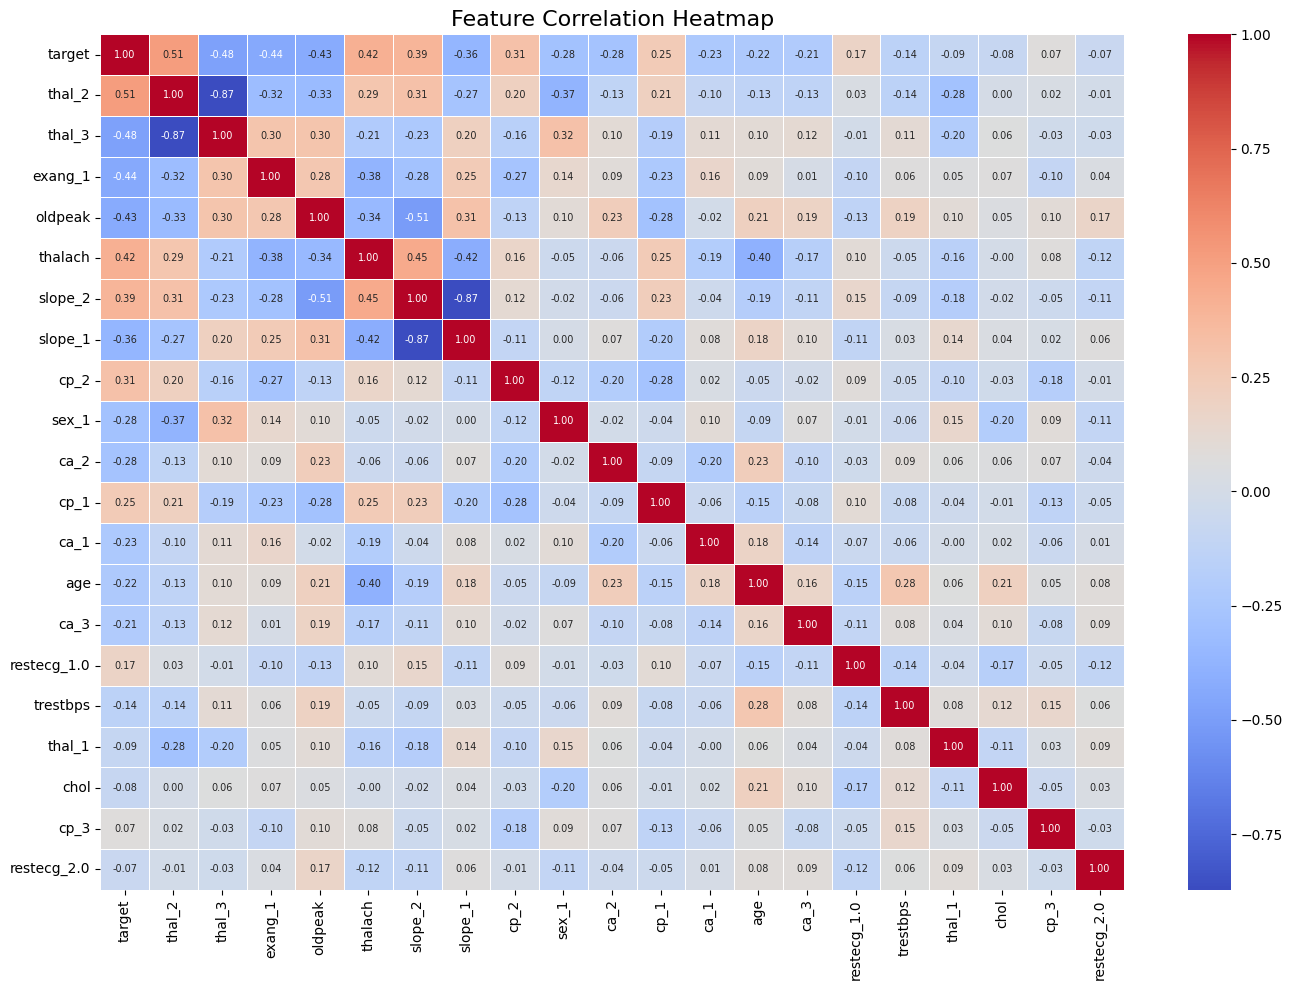

In [16]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png")
plt.show()

## — Histograms

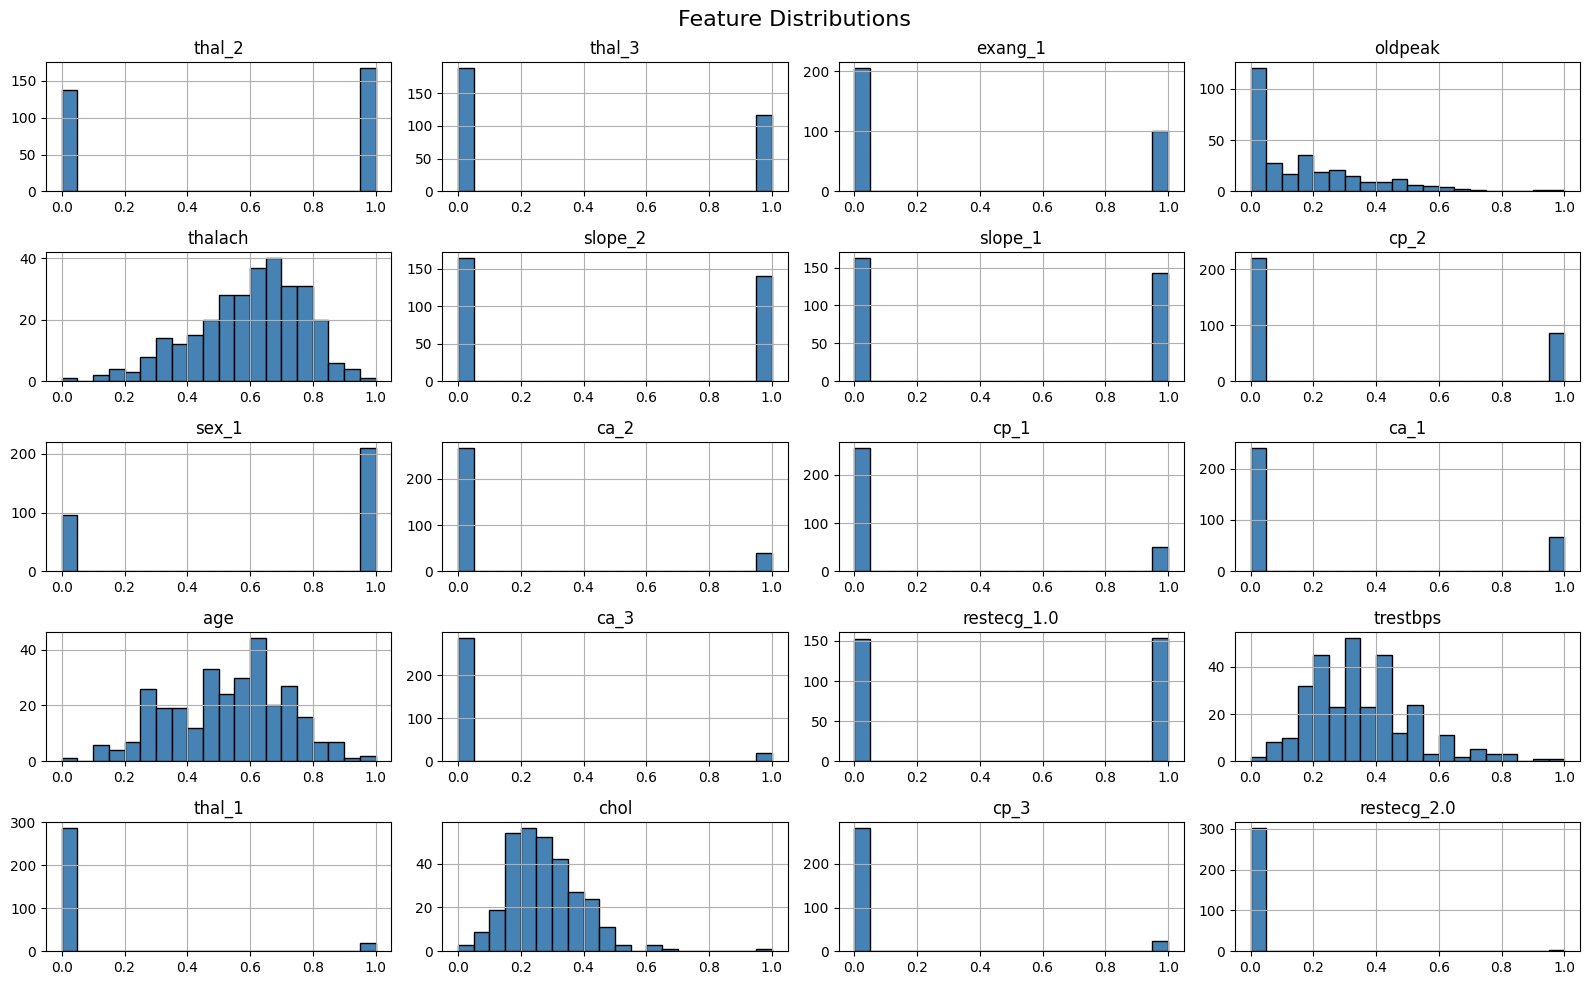

In [17]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
numerical_cols = [col for col in numerical_cols if col != TARGET_COL]

df[numerical_cols].hist(
    bins=20,
    figsize=(16, 10),
    color="steelblue",
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/histograms.png")
plt.show()

## — Boxplots

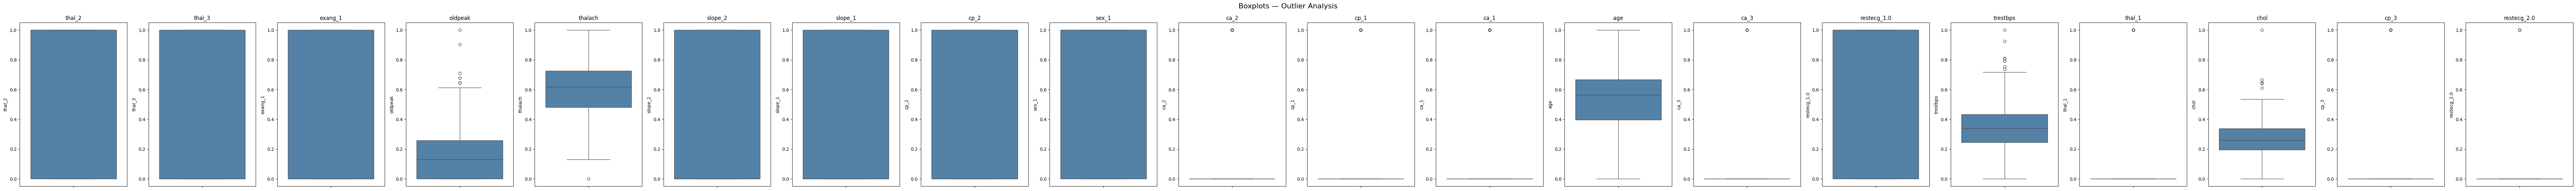

In [18]:
n = len(numerical_cols)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(col, fontsize=12)

plt.suptitle("Boxplots — Outlier Analysis", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/boxplots.png")
plt.show()

## — Feature Importance

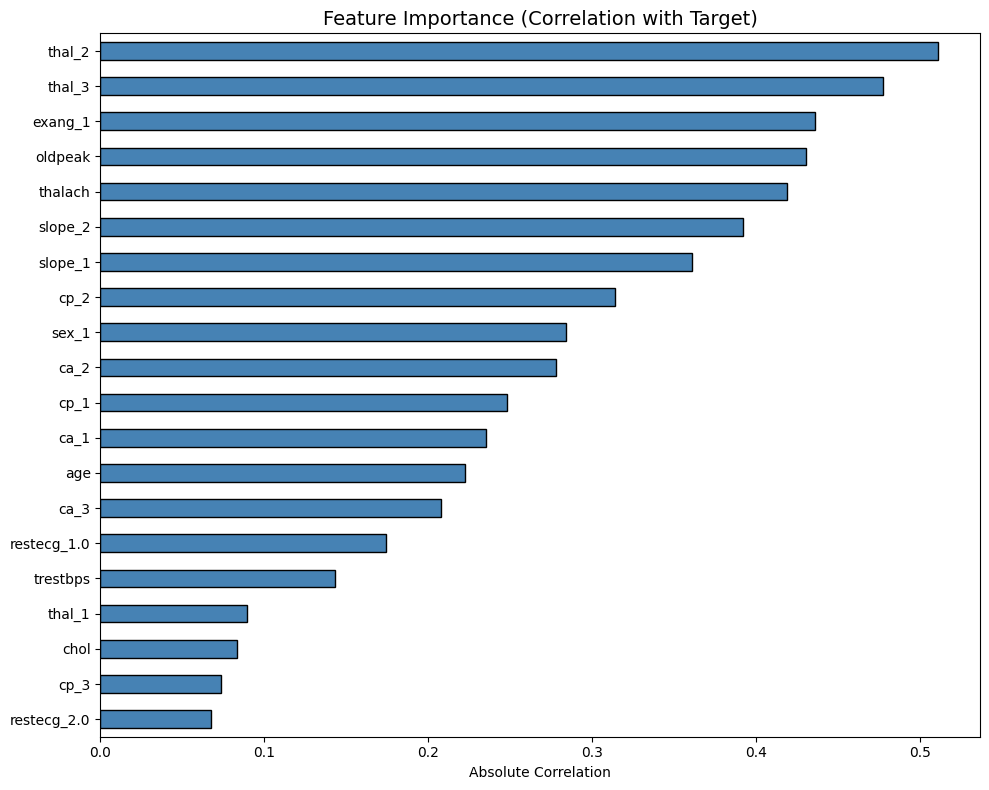

In [19]:
corr = df.corr(numeric_only=True)[TARGET_COL].abs()
corr = corr.drop(labels=[TARGET_COL], errors="ignore")
corr = corr.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
corr.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Feature Importance (Correlation with Target)", fontsize=14)
plt.xlabel("Absolute Correlation")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png")
plt.show()